In [4]:
import numpy as np
import scipy.io as sio
import scipy.ndimage as ndi
from scipy.ndimage import convolve
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd().parent / "data" / "hyperspectral_oil_spill"
device = "cuda" if torch.cuda.is_available() else "cpu"

train_files = [f for f in DATA_DIR.glob("*.mat") if f.stem not in ["GM01", "GM02"]]
test_files = [f for f in DATA_DIR.glob("*.mat") if f.stem in ["GM01", "GM02"]]
all_files = train_files + test_files

In [5]:
def evaluate_band_retention_dynamic(file_list):
    print("Dynamically calculating noise variance across ALL files to select optimal bands...")
    water_vapor_bands = set(list(range(104, 114)) + list(range(148, 168)) + list(range(221, 224)))
    sample_img = sio.loadmat(file_list[0])["img"]
    total_raw_bands = sample_img.shape[2]
    
    valid_bands = [b for b in range(total_raw_bands) if b not in water_vapor_bands]
    mask = np.array([[1, -2,  1], [-2, 4, -2], [1, -2,  1]], dtype=float)
    all_file_scores = []
    
    for file_path in tqdm(file_list, desc="Scanning datasets"):
        img = sio.loadmat(file_path)["img"]
        H, W, _ = img.shape
        scores = []
        for b in valid_bands:
            band_data = img[:, :, b].astype(float)
            p_low, p_high = np.percentile(band_data, (1, 99))
            band_norm = np.clip((band_data - p_low) / (p_high - p_low + 1e-8), 0, 1)
            
            noise = np.abs(convolve(band_norm, mask)[1:-1, 1:-1]).sum()
            sigma_n = noise * np.sqrt(np.pi / 2) / (6 * (H - 2) * (W - 2))
            scores.append(sigma_n)
        all_file_scores.append(scores)
        
    avg_sigma_per_band = np.mean(all_file_scores, axis=0)
    adaptive_threshold = np.mean(avg_sigma_per_band)
    
    ultra_clean_bands = [valid_bands[i] for i, sigma in enumerate(avg_sigma_per_band) if sigma < adaptive_threshold]
    
    print(f"Adaptive Noise Threshold: {adaptive_threshold:.4f}")
    print(f"Original valid bands: {len(valid_bands)} | Ultra-clean bands retained: {len(ultra_clean_bands)}")
    return np.sort(ultra_clean_bands).tolist()

CLEAN_BANDS = evaluate_band_retention_dynamic(all_files)

Dynamically calculating noise variance across ALL files to select optimal bands...


Scanning datasets: 100%|██████████| 18/18 [01:50<00:00,  6.13s/it]

Adaptive Noise Threshold: 0.0525
Original valid bands: 191 | Ultra-clean bands retained: 138


In [6]:
class CoTNetLayer(nn.Module):
    def __init__(self, dim, kernel_size=3):
        super().__init__()
        self.kernel_size = kernel_size
        self.key_embed = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=1, bias=False),
            nn.BatchNorm2d(dim),
            nn.ReLU(inplace=True)
        )
        self.value_embed = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(dim)
        )
        factor = 4
        self.attention_embed = nn.Sequential(
            nn.Conv2d(2 * dim, 2 * dim // factor, 1, bias=False),
            nn.BatchNorm2d(2 * dim // factor),
            nn.ReLU(inplace=True),
            nn.Conv2d(2 * dim // factor, kernel_size * kernel_size * dim, 1)
        )

    def forward(self, x):
        bs, c, h, w = x.shape
        k1 = self.key_embed(x) 
        v = self.value_embed(x).view(bs, c, -1) 
        y = torch.cat([k1, x], dim=1) 
        att = self.attention_embed(y) 
        att = att.reshape(bs, c, self.kernel_size * self.kernel_size, h, w)
        att = att.mean(2, keepdim=False).view(bs, c, -1) 
        k2 = F.softmax(att, dim=-1) * v 
        k2 = k2.view(bs, c, h, w)
        return k1 + k2 

class True_SSTNet(nn.Module):
    def __init__(self, in_bands, embed_dim=128, num_classes=1):
        super().__init__()
        self.spectral_conv = nn.Sequential(
            nn.Conv3d(1, embed_dim, kernel_size=(7, 1, 1), padding=(3, 0, 0), bias=False),
            nn.BatchNorm3d(embed_dim),
            nn.ReLU(inplace=True),
            nn.Conv3d(embed_dim, embed_dim, kernel_size=(in_bands, 1, 1), bias=False),
            nn.BatchNorm3d(embed_dim),
            nn.ReLU(inplace=True)
        )
        self.cot1 = CoTNetLayer(dim=embed_dim)
        self.cot2 = CoTNetLayer(dim=embed_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1) 
        x = self.spectral_conv(x) 
        x = x.squeeze(2) 
        x = self.cot1(x)
        x = self.cot2(x)
        x = self.pool(x).flatten(1)
        return self.classifier(x)

In [7]:
from torchinfo import summary

model = True_SSTNet(in_bands=len(CLEAN_BANDS)).to(device)
summary(model, input_size=(1, len(CLEAN_BANDS), 11, 11), 
        col_names=["input_size", "output_size", "num_params", "mult_adds"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
True_SSTNet                              [1, 138, 11, 11]          [1, 1]                    --                        --
├─Sequential: 1-1                        [1, 1, 138, 11, 11]       [1, 128, 1, 11, 11]       --                        --
│    └─Conv3d: 2-1                       [1, 1, 138, 11, 11]       [1, 128, 138, 11, 11]     896                       14,961,408
│    └─BatchNorm3d: 2-2                  [1, 128, 138, 11, 11]     [1, 128, 138, 11, 11]     256                       256
│    └─ReLU: 2-3                         [1, 128, 138, 11, 11]     [1, 128, 138, 11, 11]     --                        --
│    └─Conv3d: 2-4                       [1, 128, 138, 11, 11]     [1, 128, 1, 11, 11]       2,260,992                 273,580,032
│    └─BatchNorm3d: 2-5                  [1, 128, 1, 11, 11]       [1, 128, 1, 11, 11]       256                       25

In [8]:
model.load_state_dict(torch.load("finetuned_sstnet_138.pth", map_location=device))
model.eval()
print("Successfully loaded fine-tuned weights!")

Successfully loaded fine-tuned weights!


/tmp/ipykernel_1580709/378914838.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("finetuned_sstnet_138.pth", map_location=device))


Inferring GM01: 100%|██████████| 1661/1661 [03:38<00:00,  7.61it/s]


Generating raw neural network predictions for GM01...

--- Full Scene Raw Metrics for GM01 ---
AUC: 0.9876 | Precision: 0.3869 | Recall: 0.9625 | F1: 0.5519



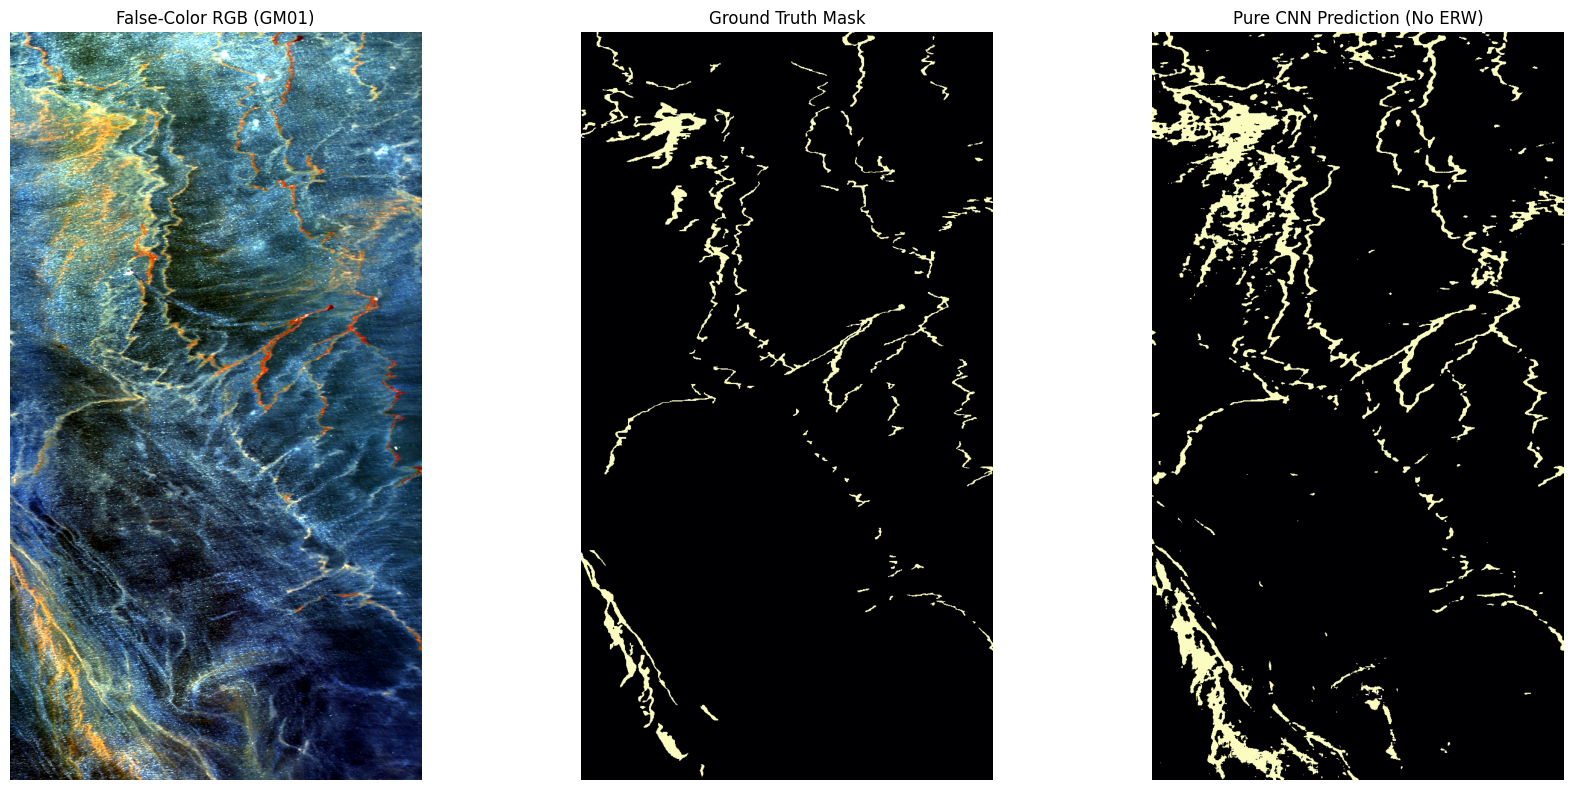

Inferring GM02: 100%|██████████| 2439/2439 [05:14<00:00,  7.76it/s]


Generating raw neural network predictions for GM02...

--- Full Scene Raw Metrics for GM02 ---
AUC: 0.9769 | Precision: 0.0370 | Recall: 0.9892 | F1: 0.0714



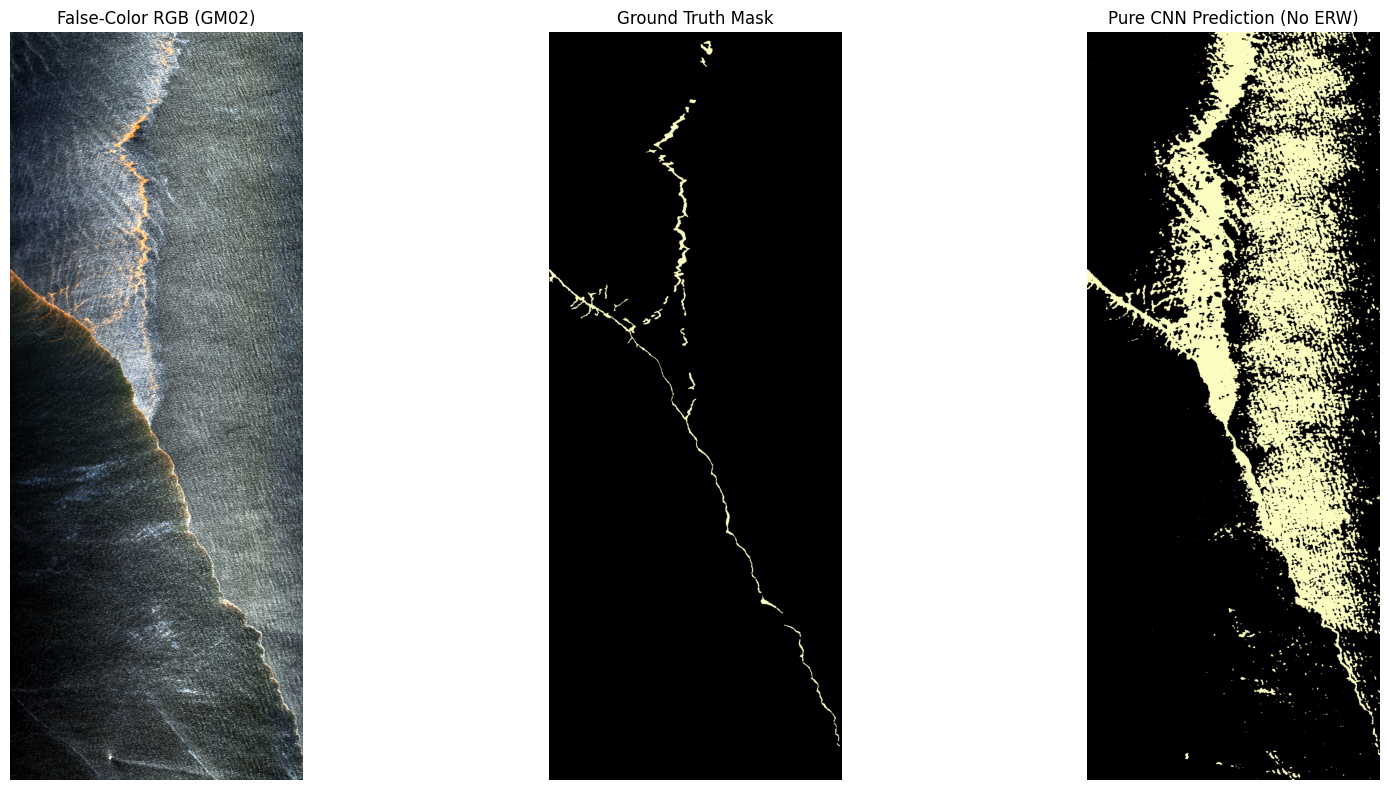

In [6]:
def plot_full_scene(model, file_path, clean_bands, device, patch_size=11):
    mat = sio.loadmat(file_path)
    img = mat["img"]
    gt = mat["map"]
    
    # Extract RGB bands 
    rgb_raw = img[:, :, [29, 19, 9]].astype(np.float32)
    rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)
    rgb_img = np.zeros_like(rgb_clean)
    for c in range(3):
        channel = rgb_clean[:, :, c]
        p_low, p_high = np.percentile(channel[channel > 0], (1, 99))
        rgb_img[:, :, c] = np.clip((channel - p_low) / (p_high - p_low + 1e-8), 0, 1)
    
    # With this robust band-wise normalization, dont use min max scaling
    img_clean = img[:, :, clean_bands].astype(np.float32)
    for b in range(img_clean.shape[2]):
        band = img_clean[:, :, b]
        # Calculate 1st and 99th percentile to ignore extreme outliers/sensor errors
        p_low, p_high = np.percentile(band, (1, 99))
        img_clean[:, :, b] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)


    pad = patch_size // 2
    img_padded = np.pad(img_clean, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
    
    H, W = gt.shape
    raw_prob_map = np.zeros((H, W))
    valid_coords = [(r, c) for r in range(H) for c in range(W) if gt[r, c] >= 0]
    
    batch_size = 512 
    model.eval()
    
    with torch.inference_mode():
        for i in tqdm(range(0, len(valid_coords), batch_size), desc=f"Inferring {file_path.stem}"):
            batch_coords = valid_coords[i:i+batch_size]
            batch = [img_padded[r:r+patch_size, c:c+patch_size, :].transpose(2, 0, 1) for r, c in batch_coords]
            
            batch_tensor = torch.tensor(np.array(batch), dtype=torch.float32).to(device)
            
            # FIX 1: Added .squeeze(1) to map shapes correctly
            probs = torch.sigmoid(model(batch_tensor).squeeze(1)).cpu().numpy()
            
            for (r, c), prob in zip(batch_coords, probs):
                raw_prob_map[r, c] = prob

    print(f"Generating raw neural network predictions for {file_path.stem}...")
    
    # FIX 2: Bypass ERW and use the raw probability map directly
    predictions = (raw_prob_map > 0.50).astype(int)
    
    # FIX 3: Mask out the invalid background swath (where gt < 0)
    valid_mask = (gt >= 0)
    predictions = predictions * valid_mask
    
    # Extract metrics using the valid coordinates
    all_probs = [raw_prob_map[r, c] for r, c in valid_coords]
    all_targets = [gt[r, c] for r, c in valid_coords]
    preds_binary = (np.array(all_probs) > 0.50).astype(int)
    
    auc = roc_auc_score(all_targets, all_probs)
    precision = precision_score(all_targets, preds_binary, zero_division=0)
    recall = recall_score(all_targets, preds_binary, zero_division=0)
    f1 = f1_score(all_targets, preds_binary, zero_division=0)
    
    print(f"\n--- Full Scene Raw Metrics for {file_path.stem} ---")
    print(f"AUC: {auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}\n")

    # Visual Plotting
    fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    axs[0].imshow(rgb_img)
    axs[0].set_title(f"False-Color RGB ({file_path.stem})")
    
    axs[1].imshow(gt == 1, cmap='magma')
    axs[1].set_title("Ground Truth Mask")
    
    axs[2].imshow(predictions, cmap='magma')
    axs[2].set_title("Pure CNN Prediction (No ERW)")
    
    for ax in axs: 
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run the evaluation on both test scenes
for test_file in test_files:
    plot_full_scene(model, test_file, CLEAN_BANDS, device)

Inferring GM01:   5%|▍         | 75/1661 [00:08<03:06,  8.51it/s]

Inferring GM01: 100%|██████████| 1661/1661 [03:12<00:00,  8.61it/s]


Finding optimal threshold for GM01...
--> MATHEMATICAL BEST THRESHOLD: 0.93
--> MAXIMIZED F1 SCORE: 0.6894



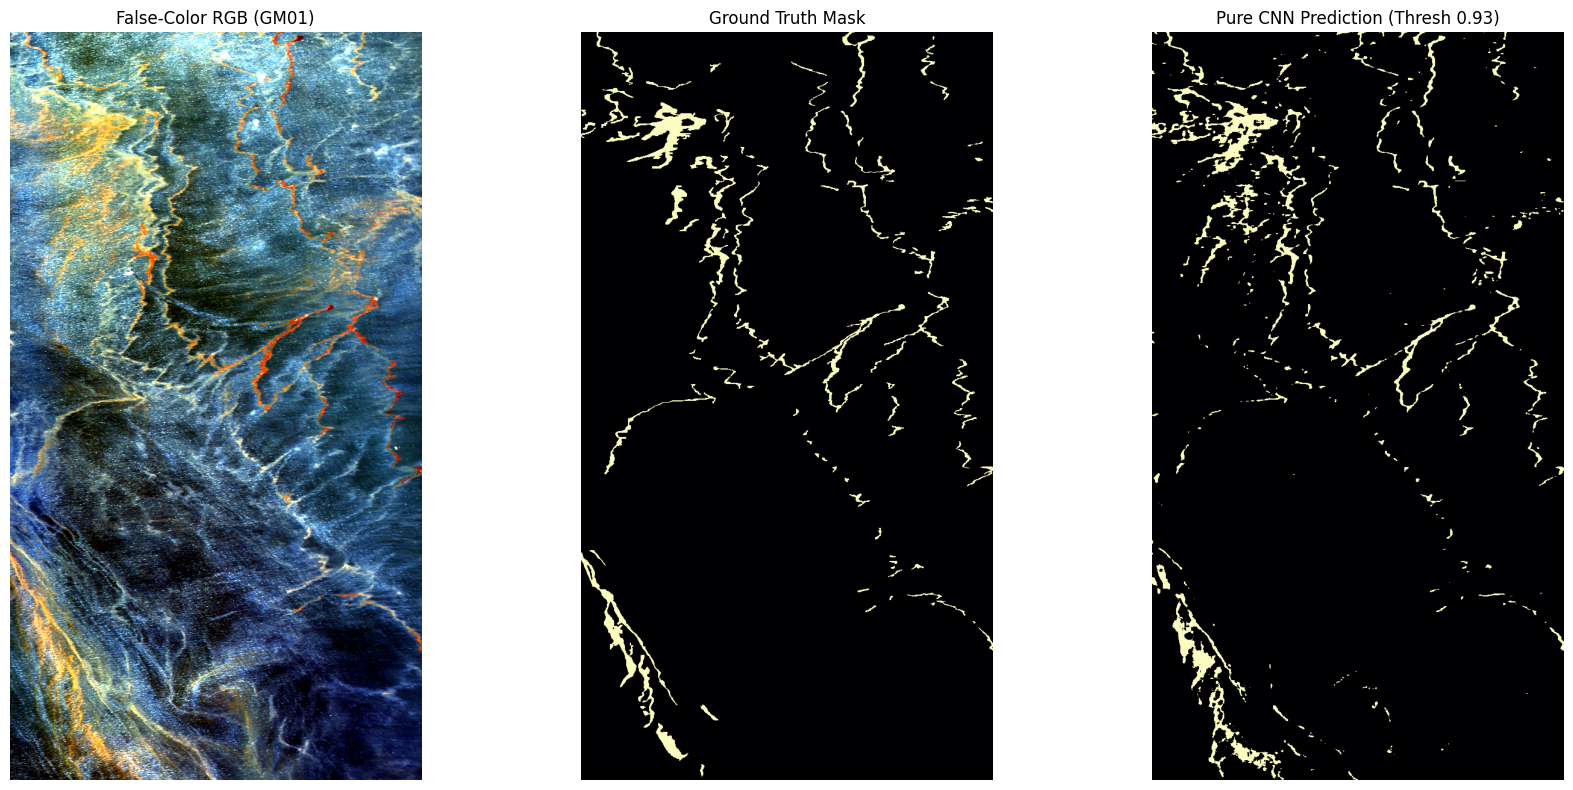

Inferring GM02: 100%|██████████| 2439/2439 [04:07<00:00,  9.84it/s]


Finding optimal threshold for GM02...
--> MATHEMATICAL BEST THRESHOLD: 0.99
--> MAXIMIZED F1 SCORE: 0.4546



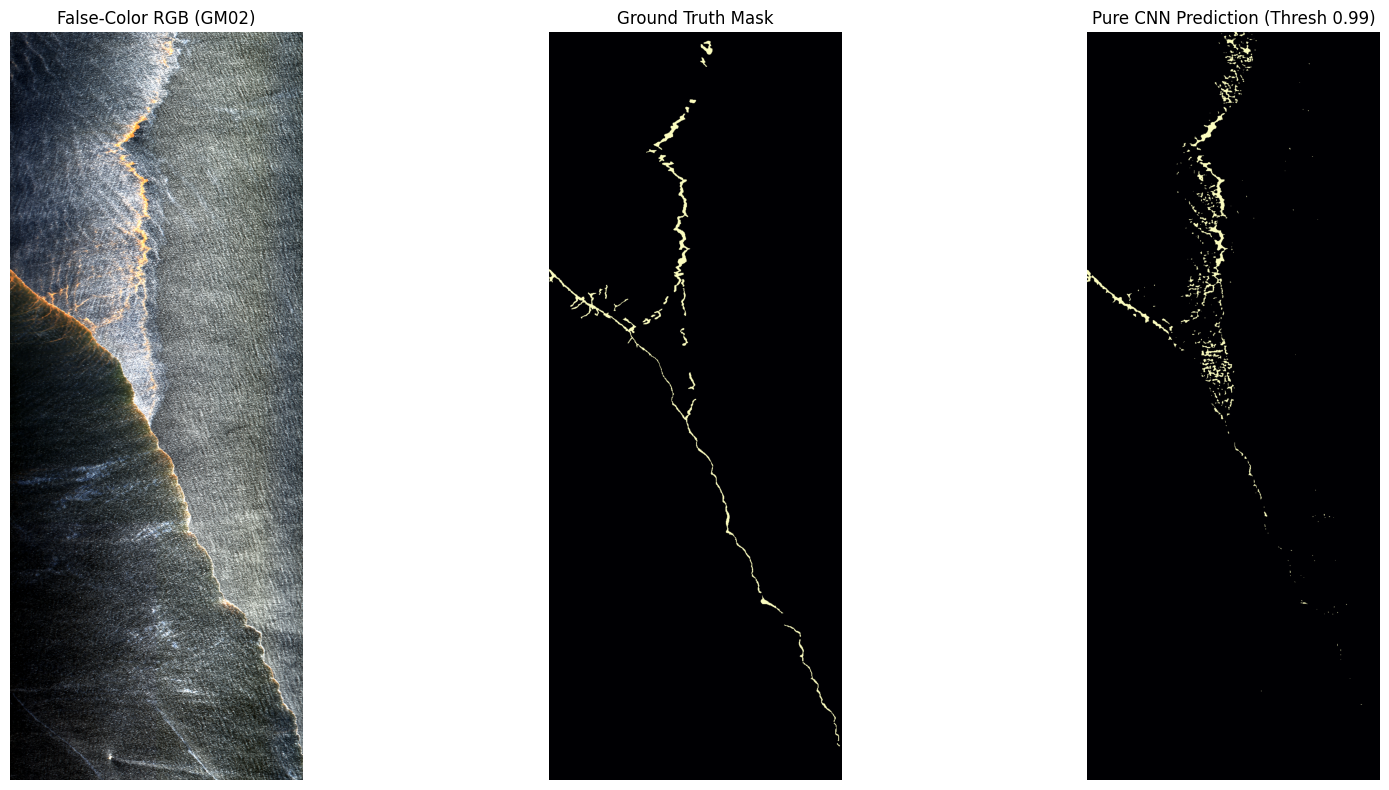

In [7]:
def plot_full_scene_raw(model, file_path, clean_bands, device, patch_size=11):
    mat = sio.loadmat(file_path)
    img, gt = mat["img"], mat["map"]
    
    # Extract RGB for visualization
    rgb_raw = img[:, :, [29, 19, 9]].astype(np.float32)
    rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)
    rgb_img = np.zeros_like(rgb_clean)
    for c in range(3):
        channel = rgb_clean[:, :, c]
        p_low, p_high = np.percentile(channel[channel > 0], (2, 98))
        rgb_img[:, :, c] = np.clip((channel - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    # Process hyperspectral data (Keeping the exact same scaling used in training)
    img_clean = img[:, :, clean_bands].astype(np.float32)
    for b in range(img_clean.shape[2]):
        band = img_clean[:, :, b]
        p_low, p_high = np.percentile(band, (1, 99)) 
        img_clean[:, :, b] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    pad = patch_size // 2
    img_padded = np.pad(img_clean, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
    
    H, W = gt.shape
    raw_prob_map = np.zeros((H, W))
    valid_coords = [(r, c) for r in range(H) for c in range(W) if gt[r, c] >= 0]
    
    batch_size = 512 
    model.eval()
    
    with torch.inference_mode():
        for i in tqdm(range(0, len(valid_coords), batch_size), desc=f"Inferring {file_path.stem}"):
            batch_coords = valid_coords[i:i+batch_size]
            batch = [img_padded[r:r+patch_size, c:c+patch_size, :].transpose(2, 0, 1) for r, c in batch_coords]
            batch_tensor = torch.tensor(np.array(batch), dtype=torch.float32).to(device)
            probs = torch.sigmoid(model(batch_tensor).squeeze(1)).cpu().numpy()
            
            for (r, c), prob in zip(batch_coords, probs):
                raw_prob_map[r, c] = prob

    # ---------------------------------------------------------
    # THRESHOLD OPTIMIZER (BYPASSING ERW)
    # ---------------------------------------------------------
    print(f"Finding optimal threshold for {file_path.stem}...")
    all_probs = [raw_prob_map[r, c] for r, c in valid_coords]
    all_targets = [gt[r, c] for r, c in valid_coords]
    
    best_f1, best_thresh = 0, 0.50
    for t in np.linspace(0.01, 0.99, 99):
        temp_preds = (np.array(all_probs) > t).astype(int)
        score = f1_score(all_targets, temp_preds, zero_division=0)
        if score > best_f1:
            best_f1, best_thresh = score, t
            
    print(f"--> MATHEMATICAL BEST THRESHOLD: {best_thresh:.2f}")
    print(f"--> MAXIMIZED F1 SCORE: {best_f1:.4f}\n")
    
    valid_mask = (gt >= 0)
    predictions = (raw_prob_map > best_thresh).astype(int) * valid_mask

    # Plot results
    fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    axs[0].imshow(rgb_img)
    axs[0].set_title(f"False-Color RGB ({file_path.stem})")
    axs[1].imshow(gt == 1, cmap='magma')
    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(predictions, cmap='magma')
    axs[2].set_title(f"Pure CNN Prediction (Thresh {best_thresh:.2f})")
    
    for ax in axs: ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run the evaluation on both test scenes
for test_file in test_files:
    plot_full_scene_raw(model, test_file, CLEAN_BANDS, device)

Inferring GM01:   8%|▊         | 128/1661 [00:10<02:08, 11.93it/s]

Inferring GM01: 100%|██████████| 1661/1661 [02:20<00:00, 11.81it/s]


Optimizing threshold & filtering GM01...
--> MATHEMATICAL BEST THRESHOLD: 0.93
--> RAW MAXIMIZED F1 SCORE: 0.6894
--> FILTERED F1 SCORE: 0.6521 (Precision: 0.6531 | Recall: 0.6511)



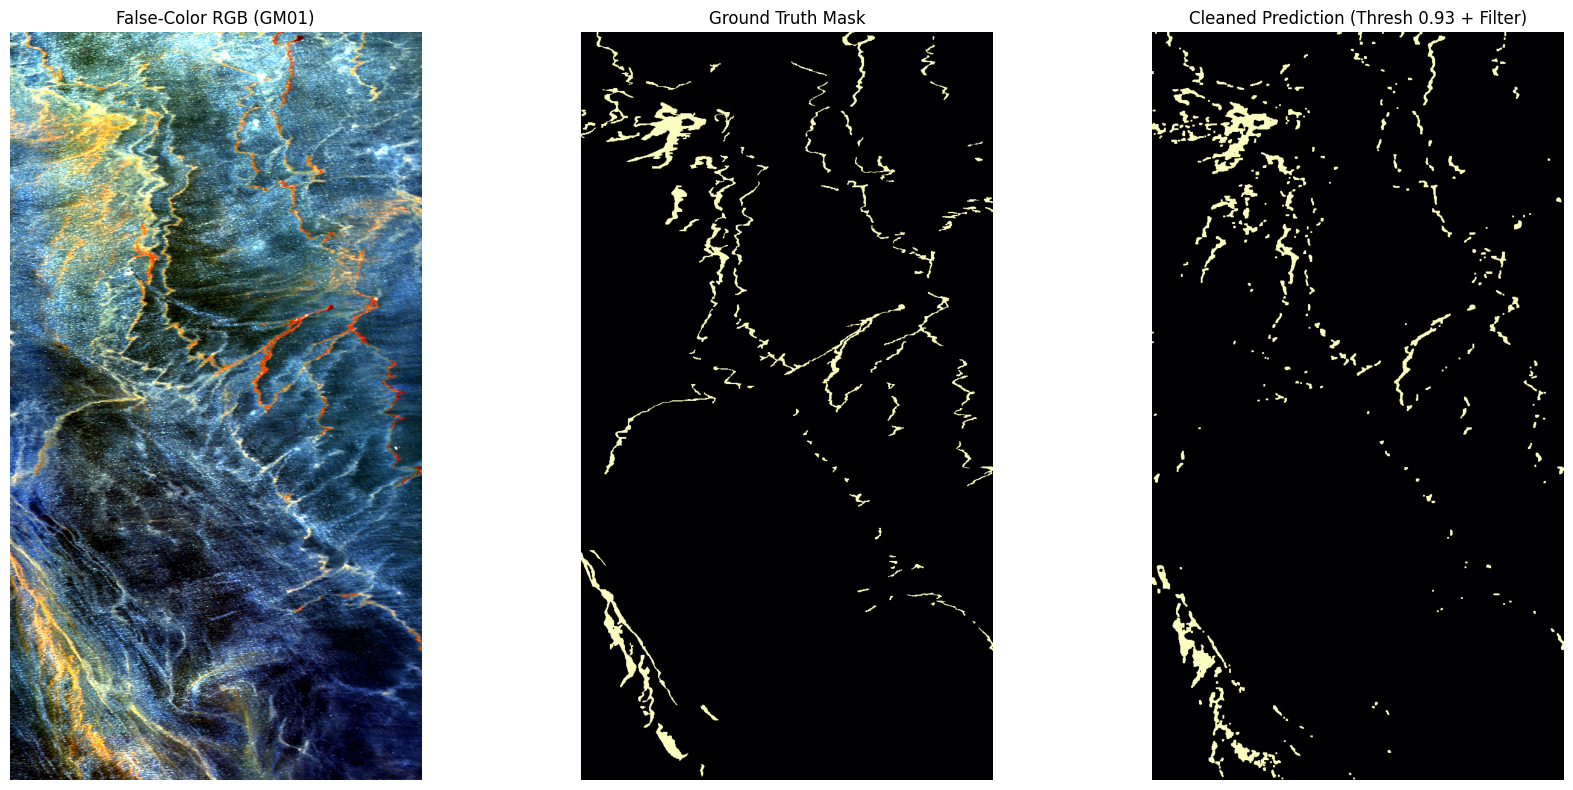

Inferring GM02: 100%|██████████| 2439/2439 [03:58<00:00, 10.21it/s]


Optimizing threshold & filtering GM02...
--> MATHEMATICAL BEST THRESHOLD: 0.99
--> RAW MAXIMIZED F1 SCORE: 0.4546
--> FILTERED F1 SCORE: 0.4531 (Precision: 0.4951 | Recall: 0.4176)



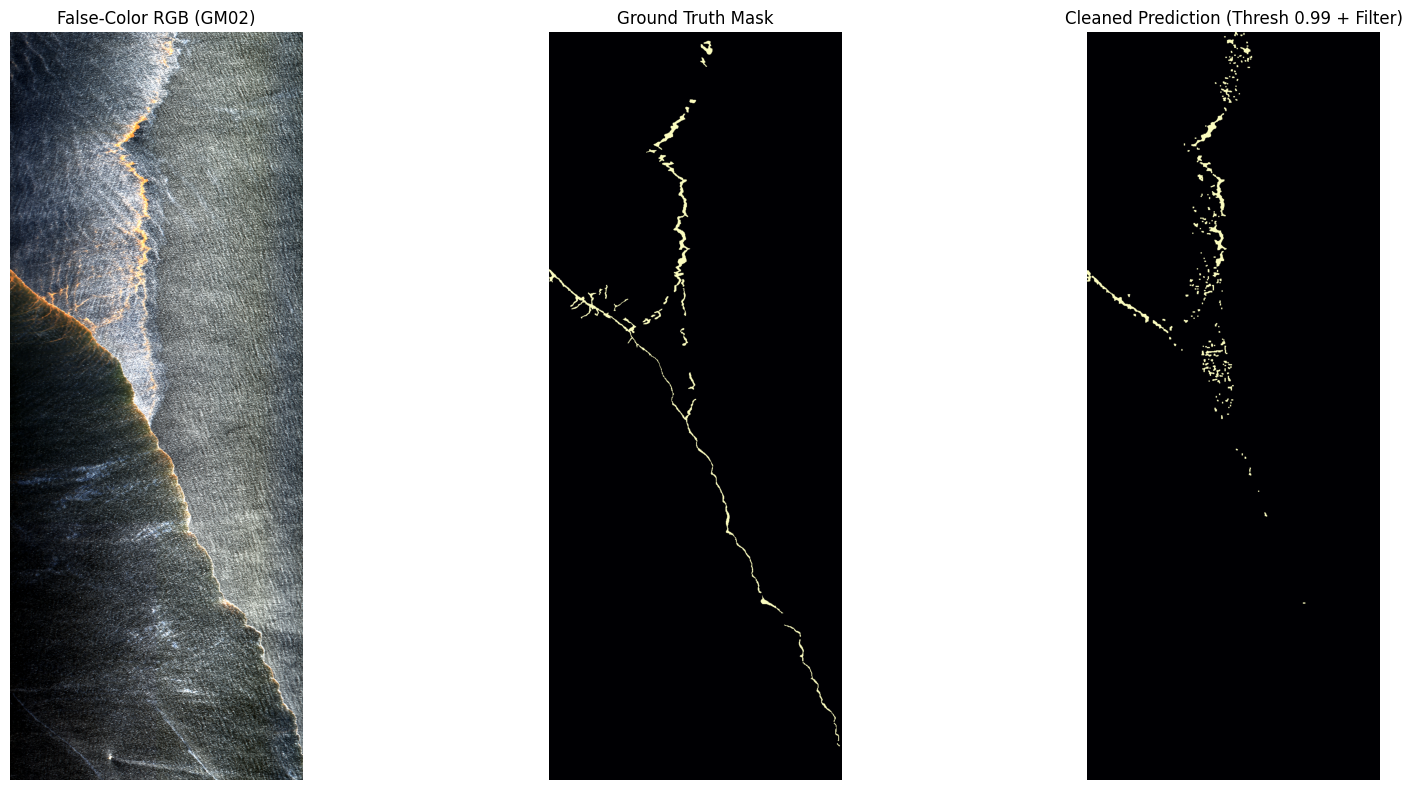

In [8]:
import scipy.ndimage as ndi

def plot_full_scene_cleaned(model, file_path, clean_bands, device, patch_size=11):
    mat = sio.loadmat(file_path)
    img, gt = mat["img"], mat["map"]
    
    # Extract RGB for visualization
    rgb_raw = img[:, :, [29, 19, 9]].astype(np.float32)
    rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)
    rgb_img = np.zeros_like(rgb_clean)
    for c in range(3):
        channel = rgb_clean[:, :, c]
        p_low, p_high = np.percentile(channel[channel > 0], (2, 98))
        rgb_img[:, :, c] = np.clip((channel - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    # Process hyperspectral data
    img_clean = img[:, :, clean_bands].astype(np.float32)
    for b in range(img_clean.shape[2]):
        band = img_clean[:, :, b]
        p_low, p_high = np.percentile(band, (1, 99)) 
        img_clean[:, :, b] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    pad = patch_size // 2
    img_padded = np.pad(img_clean, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
    
    H, W = gt.shape
    raw_prob_map = np.zeros((H, W))
    valid_coords = [(r, c) for r in range(H) for c in range(W) if gt[r, c] >= 0]
    
    batch_size = 512 
    model.eval()
    
    with torch.inference_mode():
        for i in tqdm(range(0, len(valid_coords), batch_size), desc=f"Inferring {file_path.stem}"):
            batch_coords = valid_coords[i:i+batch_size]
            batch = [img_padded[r:r+patch_size, c:c+patch_size, :].transpose(2, 0, 1) for r, c in batch_coords]
            batch_tensor = torch.tensor(np.array(batch), dtype=torch.float32).to(device)
            probs = torch.sigmoid(model(batch_tensor).squeeze(1)).cpu().numpy()
            for (r, c), prob in zip(batch_coords, probs):
                raw_prob_map[r, c] = prob

    # ---------------------------------------------------------
    # OPTIMAL THRESHOLD & MORPHOLOGICAL FILTERING (OPTION A)
    # ---------------------------------------------------------
    print(f"Optimizing threshold & filtering {file_path.stem}...")
    all_probs = [raw_prob_map[r, c] for r, c in valid_coords]
    all_targets = [gt[r, c] for r, c in valid_coords]
    
    best_f1, best_thresh = 0, 0.50
    for t in np.linspace(0.01, 0.99, 99):
        temp_preds = (np.array(all_probs) > t).astype(int)
        score = f1_score(all_targets, temp_preds, zero_division=0)
        if score > best_f1:
            best_f1, best_thresh = score, t
            
    print(f"--> MATHEMATICAL BEST THRESHOLD: {best_thresh:.2f}")
    print(f"--> RAW MAXIMIZED F1 SCORE: {best_f1:.4f}")
    
    valid_mask = (gt >= 0)
    raw_predictions = (raw_prob_map > best_thresh).astype(int) * valid_mask
    
    # Apply the Morphological Opening Filter
    cleaned_predictions = ndi.binary_opening(raw_predictions, structure=np.ones((3,3))).astype(int)
    
    # Recalculate metrics on the cleaned image
    cleaned_preds_1d = [cleaned_predictions[r, c] for r, c in valid_coords]
    precision_clean = precision_score(all_targets, cleaned_preds_1d, zero_division=0)
    recall_clean = recall_score(all_targets, cleaned_preds_1d, zero_division=0)
    f1_clean = f1_score(all_targets, cleaned_preds_1d, zero_division=0)
    
    print(f"--> FILTERED F1 SCORE: {f1_clean:.4f} (Precision: {precision_clean:.4f} | Recall: {recall_clean:.4f})\n")

    # Plot results
    fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    axs[0].imshow(rgb_img)
    axs[0].set_title(f"False-Color RGB ({file_path.stem})")
    axs[1].imshow(gt == 1, cmap='magma')
    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(cleaned_predictions, cmap='magma')
    axs[2].set_title(f"Cleaned Prediction (Thresh {best_thresh:.2f} + Filter)")
    
    for ax in axs: ax.axis("off")
    plt.tight_layout()
    plt.show()

# Run the evaluation
for test_file in test_files:
    plot_full_scene_cleaned(model, test_file, CLEAN_BANDS, device)

In [9]:
import numpy as np
import scipy.io as sio
from pathlib import Path
from tqdm.auto import tqdm
from scipy.ndimage import convolve

# Force matplotlib to run headlessly
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd().parent / "data" / "hyperspectral_oil_spill"
mat_files = list(DATA_DIR.glob("*.mat"))

# 1. Quickly grab the clean bands using our standard logic
def get_clean_bands():
    water_vapor_bands = set(list(range(104, 114)) + list(range(148, 168)) + list(range(221, 224)))
    total_raw_bands = sio.loadmat(mat_files[0])["img"].shape[2]
    valid_bands = [b for b in range(total_raw_bands) if b not in water_vapor_bands]
    
    mask = np.array([[1, -2,  1], [-2, 4, -2], [1, -2,  1]], dtype=float)
    all_scores = []
    
    # Just sample 3 files to get the clean bands quickly
    for file_path in mat_files[:3]:
        img = sio.loadmat(file_path)["img"]
        H, W, _ = img.shape
        scores = []
        for b in valid_bands:
            stripe = img[0:min(64, H-1), :, b].astype(float)
            sigma_n = np.abs(convolve(stripe, mask)[1:-1, 1:-1]).sum() * np.sqrt(np.pi / 2) / (6 * (H - 2) * (W - 2))
            scores.append(sigma_n)
        all_scores.append(scores)
        
    avg_sigma = np.mean(all_scores, axis=0)
    clean_indices = np.argsort(avg_sigma)[:144]
    return np.sort([valid_bands[i] for i in clean_indices]).tolist()

print("Calculating clean bands for accurate spectral reading...")
CLEAN_BANDS = get_clean_bands()

# 2. Analyze the Water in every scene
results = []

print("\nScanning scenes for Sun Glint and Wind Wake...")
for file_path in tqdm(mat_files):
    mat = sio.loadmat(file_path)
    img, gt = mat["img"], mat["map"]
    
    # Normalize exactly how the CNN will see it
    img_clean = img[:, :, CLEAN_BANDS].astype(np.float32)
    for b in range(img_clean.shape[2]):
        band = img_clean[:, :, b]
        p_low, p_high = np.percentile(band, (1, 99))
        img_clean[:, :, b] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)
    
    # Calculate average intensity across all clean bands to create a 2D grayscale map
    intensity_map = np.mean(img_clean, axis=2)
    
    # Isolate ONLY the known water
    water_mask = (gt == 0)
    water_pixels = intensity_map[water_mask]
    
    if len(water_pixels) == 0:
        continue
        
    # Glint metrics
    mean_brightness = np.mean(water_pixels)
    speckle_variance = np.std(water_pixels)
    extreme_glint = np.percentile(water_pixels, 98) # How bright is the top 2% of water?
    
    results.append({
        'name': file_path.stem,
        'mean': mean_brightness,
        'variance': speckle_variance,
        'glint_peak': extreme_glint,
        'intensity_map': intensity_map,
        'water_mask': water_mask
    })

# 3. Sort by Variance (highest speckle/glint first)
results.sort(key=lambda x: x['variance'], reverse=True)

print("\n--- WATER TEXTURE ANALYSIS (Sorted by Speckle/Glint Severity) ---")
print(f"{'Scene':<10} | {'Mean Brightness':<18} | {'Variance (Speckle)':<18} | {'98th Pct (Peak Glint)':<18}")
print("-" * 75)
for res in results:
    marker = " <--- (Testing Scene)" if res['name'] in ["GM01", "GM02"] else ""
    print(f"{res['name']:<10} | {res['mean']:<18.4f} | {res['variance']:<18.4f} | {res['glint_peak']:<18.4f}{marker}")

# 4. Generate Visual Heatmaps for the Top 3 Glintiest Training Scenes
print("\nGenerating heatmaps for the 3 glintiest training scenes...")
top_train_scenes = [r for r in results if r['name'] not in ["GM01", "GM02"]][:3]

for res in top_train_scenes:
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    # Only show intensity where water is present (mask out oil/background)
    water_only_display = res['intensity_map'].copy()
    water_only_display[~res['water_mask']] = 0 
    
    axs[0].imshow(water_only_display, cmap='gray')
    axs[0].set_title(f"{res['name']} Raw Water Intensity")
    
    # Heatmap showing where the intensity exceeds normal calm water
    # (Highlighting the glint in bright red/yellow)
    axs[1].imshow(water_only_display, cmap='magma', vmin=0, vmax=res['glint_peak'])
    axs[1].set_title(f"{res['name']} Glint Heatmap")
    
    for ax in axs: ax.axis('off')
    plt.tight_layout()
    
    out_name = f"glint_analysis_{res['name']}.png"
    plt.savefig(out_name, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_name}")

print("\nScript complete. Review the table and PNG files.")

Calculating clean bands for accurate spectral reading...

Scanning scenes for Sun Glint and Wind Wake...


 17%|█▋        | 3/18 [00:08<00:41,  2.78s/it]

100%|██████████| 18/18 [01:20<00:00,  4.48s/it]



--- WATER TEXTURE ANALYSIS (Sorted by Speckle/Glint Severity) ---
Scene      | Mean Brightness    | Variance (Speckle) | 98th Pct (Peak Glint)
---------------------------------------------------------------------------
GM02       | 0.3070             | 0.2049             | 0.8191             <--- (Testing Scene)
GM03       | 0.2279             | 0.1235             | 0.5573            
GM01       | 0.2141             | 0.1217             | 0.5563             <--- (Testing Scene)
GM04       | 0.1988             | 0.1023             | 0.4878            
GM06       | 0.2375             | 0.0968             | 0.4928            
GM07       | 0.2593             | 0.0924             | 0.4812            
GM12       | 0.1950             | 0.0900             | 0.4410            
GM05       | 0.2107             | 0.0864             | 0.4246            
GM08       | 0.2436             | 0.0824             | 0.4527            
GM09       | 0.3238             | 0.0819             | 0.4927           